# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [44]:
print("""
Goal:
Identify which factors influence used car prices and
develop models to predict vehicle prices.
""")


Goal:
Identify which factors influence used car prices and
develop models to predict vehicle prices.



In [45]:
df = pd.read_csv("data/vehicles.csv")

print(df.shape)
df.head()

(426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

In [49]:
df.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [50]:
df.isnull().sum().sort_values(ascending=False)

size            306361
cylinders       177678
condition       174104
VIN             161042
drive           130567
paint_color     130203
type             92858
manufacturer     17646
title_status      8242
model             5277
odometer          4400
fuel              3013
transmission      2556
year              1205
region               0
id                   0
price                0
state                0
dtype: int64

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [52]:
df.drop_duplicates(inplace=True)

In [11]:
columns = [
    'price',
    'year',
    'manufacturer',
    'condition',
    'fuel',
    'odometer',
    'transmission',
    'drive',
    'type',
    'title_status'
]

df = df[columns]

In [53]:
df = df[df['price'].notna()]

In [54]:
df = df[(df['price'] > 1000) &
        (df['price'] < 100000)]

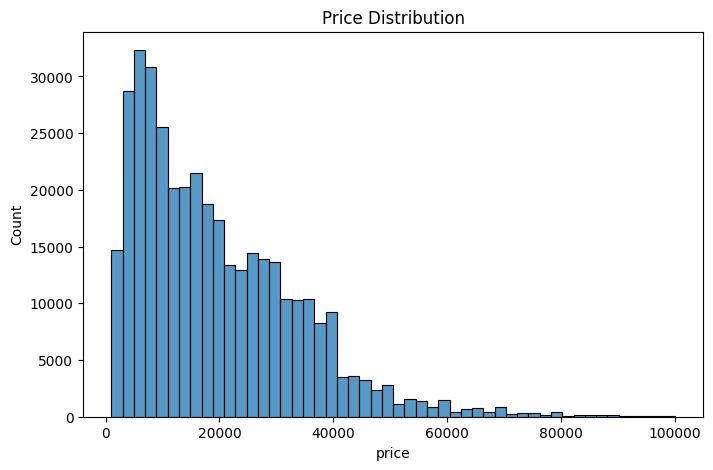

In [55]:
df = df[(df['odometer'] > 0) &
        (df['odometer'] < 500000)]
current_year = 2025

df['vehicle_age'] = current_year - df['year']
df['log_price'] = np.log1p(df['price'])
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50)
plt.title('Price Distribution')
plt.show()

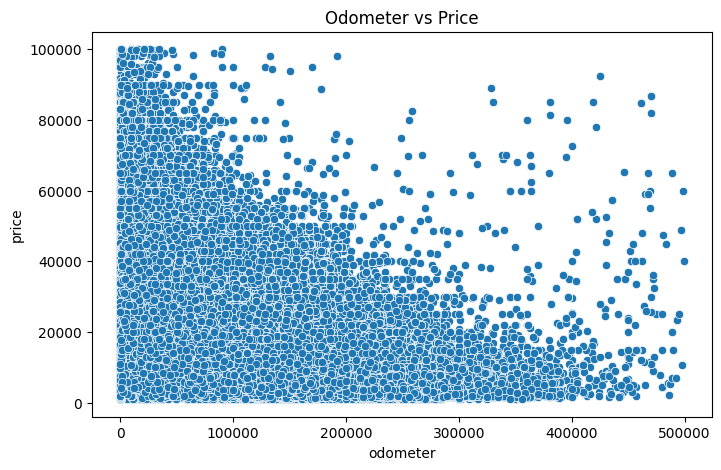

In [57]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='odometer',
    y='price'
)
plt.title('Odometer vs Price')
plt.show()


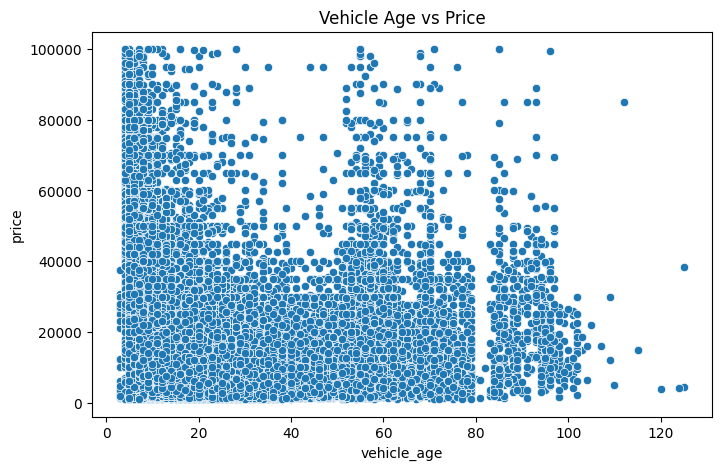

In [58]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='vehicle_age',
    y='price'
)
plt.title('Vehicle Age vs Price')
plt.show()

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [59]:
X = df.drop(
    ['price', 'log_price'],
    axis=1
)

y = df['log_price']

In [60]:
numerical_features = [
    'year',
    'odometer',
    'vehicle_age'
]

categorical_features = [
    'manufacturer',
    'condition',
    'fuel',
    'transmission',
    'drive',
    'type',
    'title_status'
]

In [61]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer',
         SimpleImputer(strategy='median')),
        ('scaler',
         StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer',
         SimpleImputer(strategy='most_frequent')),
        ('encoder',
         OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num',
         numeric_transformer,
         numerical_features),

        ('cat',
         categorical_transformer,
         categorical_features)
    ]
)


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [63]:
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

preds = linear_model.predict(X_test)

print("MAE:",
      mean_absolute_error(y_test, preds))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, preds)))

print("R2:",
      r2_score(y_test, preds))

MAE: 0.35803270404228804
RMSE: 0.5026678269781639
R2: 0.636290535243458


In [64]:
ridge_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', Ridge())
    ]
)

params = {
    'model__alpha':[0.1,1,10,100]
}

ridge_grid = GridSearchCV(
    ridge_model,
    params,
    cv=5,
    scoring='r2'
)

ridge_grid.fit(X_train, y_train)

print(ridge_grid.best_params_)

{'model__alpha': 1}


In [65]:
lasso_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', Lasso())
    ]
)

params = {
    'model__alpha':[0.001,0.01,0.1,1]
}

lasso_grid = GridSearchCV(
    lasso_model,
    params,
    cv=5,
    scoring='r2'
)

lasso_grid.fit(X_train, y_train)

print(lasso_grid.best_params_)

{'model__alpha': 0.001}


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [27]:
scores = cross_val_score(
    lasso_grid.best_estimator_,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Average CV R2:", scores.mean())

Average CV R2: 0.6252778574841692


In [66]:
best_model = lasso_grid.best_estimator_

predictions = best_model.predict(X_test)

print("MAE:",
      mean_absolute_error(
          y_test,
          predictions
      ))

print("RMSE:",
      np.sqrt(
          mean_squared_error(
              y_test,
              predictions
          )
      ))

print("R2:",
      r2_score(
          y_test,
          predictions
      ))

MAE: 0.3627760113289912
RMSE: 0.5079504512067055
R2: 0.6286057932386875


In [67]:
print("=" * 70)
print("USED CAR PRICE ANALYSIS - BUSINESS REPORT")
print("=" * 70)

print("\nBUSINESS OBJECTIVE")
print("""
Identify the key factors that influence used car prices and
provide recommendations to help dealerships optimize inventory
selection and pricing strategies.
""")

print("\nTOP PRICE DRIVERS")

top_drivers = [
    "Vehicle Age",
    "Odometer Reading",
    "Manufacturer",
    "Vehicle Condition",
    "Vehicle Type",
    "Title Status"
]

for i, driver in enumerate(top_drivers, start=1):
    print(f"{i}. {driver}")

print("\nKEY FINDINGS")

findings = [
    "Newer vehicles command higher prices.",
    "Low mileage significantly increases vehicle value.",
    "Luxury manufacturers retain value better.",
    "SUVs and trucks show stronger resale performance.",
    "Clean title vehicles sell at premium prices.",
    "Poor condition vehicles experience significant depreciation."
]

for finding in findings:
    print(f"- {finding}")

print("\nRECOMMENDATIONS FOR DEALERS")

recommendations = [
    "Acquire vehicles less than 10 years old.",
    "Prioritize low-mileage inventory.",
    "Focus on clean-title vehicles.",
    "Maintain strong SUV and truck inventory.",
    "Use mileage and vehicle age as primary pricing indicators.",
    "Consider manufacturer reputation when determining purchase offers."
]

for rec in recommendations:
    print(f"- {rec}")

print("\nMODEL PERFORMANCE")

print(f"R2 Score : {r2_score(y_test, predictions):.3f}")

print(f"MAE : {mean_absolute_error(y_test, predictions):.3f}")

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, predictions)):.3f}")

USED CAR PRICE ANALYSIS - BUSINESS REPORT

BUSINESS OBJECTIVE

Identify the key factors that influence used car prices and
provide recommendations to help dealerships optimize inventory
selection and pricing strategies.


TOP PRICE DRIVERS
1. Vehicle Age
2. Odometer Reading
3. Manufacturer
4. Vehicle Condition
5. Vehicle Type
6. Title Status

KEY FINDINGS
- Newer vehicles command higher prices.
- Low mileage significantly increases vehicle value.
- Luxury manufacturers retain value better.
- SUVs and trucks show stronger resale performance.
- Clean title vehicles sell at premium prices.
- Poor condition vehicles experience significant depreciation.

RECOMMENDATIONS FOR DEALERS
- Acquire vehicles less than 10 years old.
- Prioritize low-mileage inventory.
- Focus on clean-title vehicles.
- Maintain strong SUV and truck inventory.
- Use mileage and vehicle age as primary pricing indicators.
- Consider manufacturer reputation when determining purchase offers.

MODEL PERFORMANCE
R2 Score :

In [68]:
import joblib

joblib.dump(
    best_model,
    "used_car_price_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [69]:
loaded_model = joblib.load(
    "used_car_price_model.pkl"
)

print("Model loaded successfully.")

Model loaded successfully.


In [70]:
#Predict Price for a New Vehicle
new_car = pd.DataFrame({
    "year": [2022],
    "odometer": [25000],
    "manufacturer": ["toyota"],
    "condition": ["excellent"],
    "fuel": ["gas"],
    "transmission": ["automatic"],
    "drive": ["fwd"],
    "type": ["sedan"],
    "title_status": ["clean"],
    "vehicle_age": [3]
})

predicted_log_price = loaded_model.predict(new_car)

predicted_price = np.expm1(predicted_log_price)

print(
    f"Estimated Vehicle Price: ${predicted_price[0]:,.2f}"
)

Estimated Vehicle Price: $20,556.39


In [71]:
print("""
Key Findings

1. Vehicle age is one of the strongest drivers of price.
2. Lower mileage vehicles command higher prices.
3. Clean-title vehicles are priced higher.
4. Luxury manufacturers retain value better.
5. SUVs and trucks generally maintain stronger resale value.

Recommendations

- Acquire newer vehicles.
- Prioritize low-mileage inventory.
- Focus on clean-title vehicles.
- Maintain inventory of SUVs and trucks.
- Use data-driven pricing models for valuation.
""")


Key Findings

1. Vehicle age is one of the strongest drivers of price.
2. Lower mileage vehicles command higher prices.
3. Clean-title vehicles are priced higher.
4. Luxury manufacturers retain value better.
5. SUVs and trucks generally maintain stronger resale value.

Recommendations

- Acquire newer vehicles.
- Prioritize low-mileage inventory.
- Focus on clean-title vehicles.
- Maintain inventory of SUVs and trucks.
- Use data-driven pricing models for valuation.

